<a href="https://colab.research.google.com/github/fc63/gender-classification/blob/main/model_24750_evaluation/1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets transformers torch evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import warnings
import evaluate
import pandas as pd
import numpy as np
import os
import re
import pickle
import gc
import torch
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, TrainerCallback
from tqdm import tqdm
from google.colab import drive
from transformers import EarlyStoppingCallback

drive.mount('/content/drive')

with open('/content/drive/MyDrive/datasets/europarl_normalized.pkl', 'rb') as f:
    df = pickle.load(f)

Mounted at /content/drive


In [3]:
print(df['gender'].value_counts())

min_count = df['gender'].value_counts().min()

df = (
    df.groupby('gender', group_keys=False)
    .apply(lambda x: x.sample(n=min_count, random_state=63))
    .reset_index(drop=True)
)

print(df['gender'].value_counts())

gender
male      740894
female    360361
Name: count, dtype: int64
gender
female    360361
male      360361
Name: count, dtype: int64


<ipython-input-3-e34e100695cf>:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_count, random_state=63))


In [4]:
# encode labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['gender'])

df

,text,gender,label
0,"Cooperation is not only in our interest, but i...",female,0
1,"During the committee's first meeting, we enter...",female,0
2,"Towards the end of the debate on the matter, a...",female,0
3,"After all, something is obviously being set in...",female,0
4,"Today, the new Member States in particular req...",female,0
...,...,...,...
720717,"Their function, as I understand it, is to diss...",male,1
720718,That is my first point.,male,1
720719,What we need to do tomorrow is to accept the c...,male,1
720720,in writing. I welcome this report which:,male,1


In [5]:
print(label_encoder.classes_)
print(df['label'].value_counts())

['female' 'male']
label
0    360361
1    360361
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.21, random_state=63)

test_df = {"text": list(X_test), "label": list(y_test)}
eval_dataset = Dataset.from_dict(test_df)

tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/models/gp_model_24750", use_fast=False)

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

eval_dataset = eval_dataset.map(tokenize_function, batched=True)
eval_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# model yükle
model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/models/gp_model_24750")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if not isinstance(logits, torch.Tensor):
        logits = torch.tensor(logits)
    if not isinstance(labels, torch.Tensor):
        labels = torch.tensor(labels)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    preds = logits.argmax(dim=1).to(device)
    labels = labels.to(device)

    num_classes = torch.max(labels).item() + 1
    f1_total = 0.0
    precision_total = 0.0
    recall_total = 0.0

    for cls in range(num_classes):
        tp = ((preds == cls) & (labels == cls)).sum()
        fp = ((preds == cls) & (labels != cls)).sum()
        fn = ((preds != cls) & (labels == cls)).sum()

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        precision_total += precision
        recall_total += recall
        f1_total += f1

    macro_precision = precision_total / num_classes
    macro_recall = recall_total / num_classes
    macro_f1 = f1_total / num_classes

    accuracy = (preds == labels).sum().float() / labels.shape[0]

    return {
        "f1": macro_f1.item(),
        "precision": macro_precision.item(),
        "recall": macro_recall.item(),
        "accuracy": accuracy.item()
    }

from transformers import TrainingArguments
training_args = TrainingArguments(
    output_dir="/content/dummy",
    per_device_eval_batch_size=64,
    dataloader_drop_last=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

Map:   0%|          | 0/151352 [00:00<?, ? examples/s]

<ipython-input-6-46aae0c2f174>:72: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Classification Report:
              precision    recall  f1-score   support

      female       0.62      0.56      0.59     75857
        male       0.60      0.66      0.63     75495

    accuracy                           0.61    151352
   macro avg       0.61      0.61      0.61    151352
weighted avg       0.61      0.61      0.61    151352



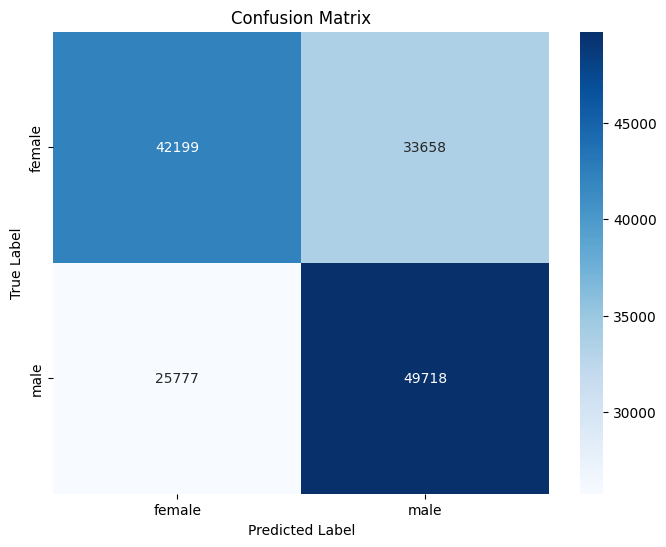

In [7]:
# visualization
predictions = trainer.predict(eval_dataset)
predicted_labels = np.argmax(predictions.predictions, axis=1)

# classification report
print("Classification Report:")
print(classification_report(y_test, predicted_labels, target_names=label_encoder.classes_))

# confusion matrix
conf_matrix = confusion_matrix(y_test, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

=== Classification Report ===
              precision    recall  f1-score   support

      female       0.62      0.56      0.59     75857
        male       0.60      0.66      0.63     75495

    accuracy                           0.61    151352
   macro avg       0.61      0.61      0.61    151352
weighted avg       0.61      0.61      0.61    151352



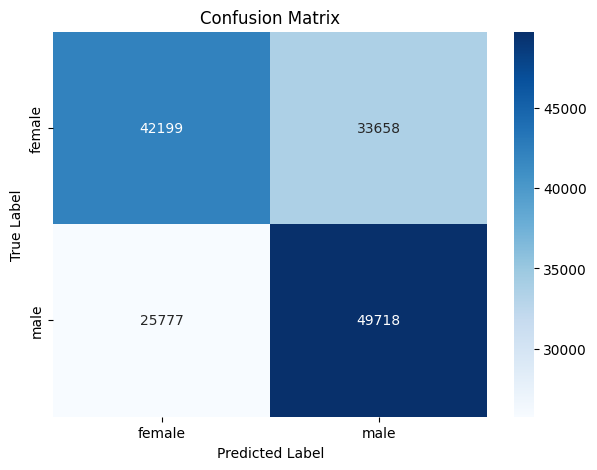

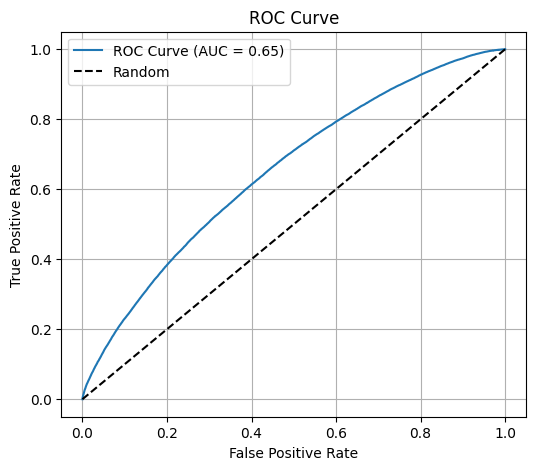

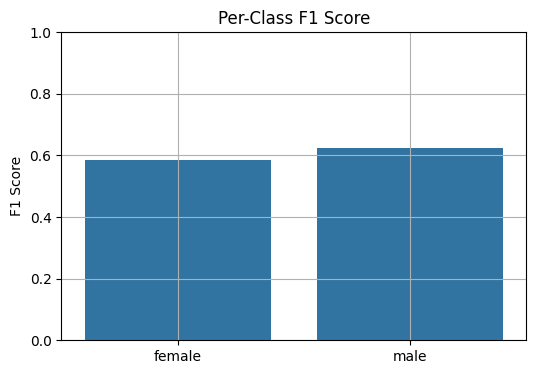

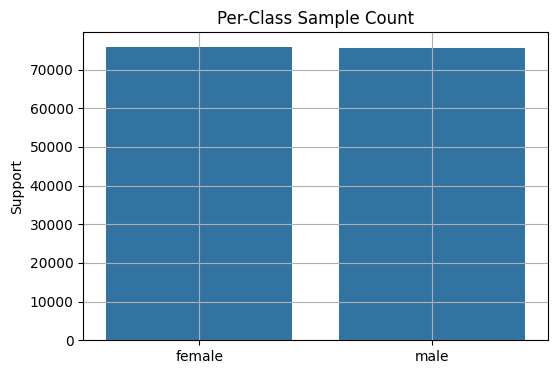

🔁 En çok karıştırılan sınıflar: 'female' ↔ 'male'

⚠️ 59435 yanlış tahmin var. Örneklerden 5 tanesi:

Text: Yesterday I waited 40 minutes to say that I was submitting my explanation of the vote in writing!
True Label: female
Predicted: male
------------------------------------------------------------
Text: Of course, these agreements are also of interest at the regional level. They will contribute to the efforts the Union has made to strengthen cooperation with other countries in the Southern Caucasus region as well.
True Label: female
Predicted: male
------------------------------------------------------------
Text: Wind generators which destroy the environment, as in the Aegean Islands, sharply increased tolls on major public roads, private and public sector collaborations and so on all are for the sake of profit made from contracting with individuals, and, of course, they are backed by state guarantees.
True Label: female
Predicted: male
---------------------------------------------

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def evaluation_report(trainer, eval_dataset, y_test, label_encoder, X_test, sample_count=5):
    # prediction
    predictions = trainer.predict(eval_dataset)
    predicted_labels = np.argmax(predictions.predictions, axis=1)
    probs = predictions.predictions[:, 1]  # pozitif sınıf için olasılık

    # classification report
    print("=== Classification Report ===")
    print(classification_report(y_test, predicted_labels, target_names=label_encoder.classes_))

    # confusion matrix
    conf_matrix = confusion_matrix(y_test, predicted_labels)
    plt.figure(figsize=(7, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Per-class F1 Barplot
    report_dict = classification_report(y_test, predicted_labels,
                                        target_names=label_encoder.classes_,
                                        output_dict=True)
    f1_scores = [report_dict[cls]["f1-score"] for cls in label_encoder.classes_]
    plt.figure(figsize=(6, 4))
    sns.barplot(x=label_encoder.classes_, y=f1_scores)
    plt.title("Per-Class F1 Score")
    plt.ylabel("F1 Score")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()

    # Support (Sample Count) Barplot
    support = [report_dict[cls]["support"] for cls in label_encoder.classes_]
    plt.figure(figsize=(6, 4))
    sns.barplot(x=label_encoder.classes_, y=support)
    plt.title("Per-Class Sample Count")
    plt.ylabel("Support")
    plt.grid(True)
    plt.show()

    # Most Confused Pair
    tmp_conf = conf_matrix.copy()
    np.fill_diagonal(tmp_conf, 0)
    confused_pair = np.unravel_index(np.argmax(tmp_conf), tmp_conf.shape)
    cls_1 = label_encoder.classes_[confused_pair[0]]
    cls_2 = label_encoder.classes_[confused_pair[1]]
    print(f"🔁 En çok karıştırılan sınıflar: '{cls_1}' ↔ '{cls_2}'")

    # Show Misclassified Samples
    wrong_idx = np.where(predicted_labels != y_test)[0]
    print(f"\n⚠️ {len(wrong_idx)} yanlış tahmin var. Örneklerden {sample_count} tanesi:\n")
    for i in np.random.choice(wrong_idx, size=min(sample_count, len(wrong_idx)), replace=False):
        print(f"Text: {X_test.iloc[i]}")
        print(f"True Label: {label_encoder.inverse_transform([y_test.iloc[i]])[0]}")
        print(f"Predicted: {label_encoder.inverse_transform([predicted_labels[i]])[0]}")
        print("-" * 60)

evaluation_report(trainer, eval_dataset, y_test, label_encoder, X_test)